In [30]:
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
df = pd.read_csv("venta_libros.csv")

In [19]:
df.head()

,titulos,precios,valoraciones
0,A Light in the ...,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,In Her Wake,£12.84,One


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   titulos       984 non-null    object
 1   precios       984 non-null    object
 2   valoraciones  984 non-null    object
dtypes: object(3)
memory usage: 23.2+ KB


In [5]:
df.loc[df["precios"].idxmax()]

titulos         The Perfect Play (Play ...
precios                             £59.99
valoraciones                         Three
Name: 632, dtype: object

In [6]:
df.head()

,titulos,precios,valoraciones
0,A Light in the ...,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,In Her Wake,£12.84,One


In [7]:
df["valoraciones"].value_counts()

valoraciones
One      222
Three    201
Two      193
Five     192
Four     176
Name: count, dtype: int64

In [14]:
df["precios"] = df["precios"].str.replace("£", "").astype(float)

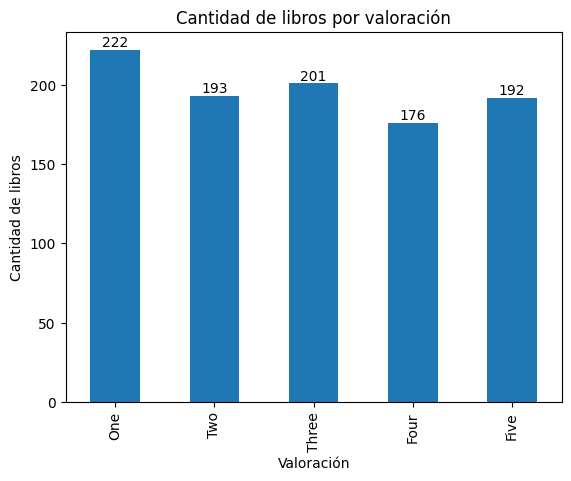

In [22]:
datos =df["valoraciones"].value_counts().reindex(
    ["One","Two","Three","Four","Five"]
)
ax=datos.plot(kind="bar")
plt.title("Cantidad de libros por valoración")
plt.xlabel("Valoración")
plt.ylabel("Cantidad de libros")


for i, valor in enumerate(datos):
    ax.text(i,valor,str(valor), ha="center",va="bottom")

plt.show()

In [28]:
df["precios"] = df["precios"].str.replace("£", "").astype(float)

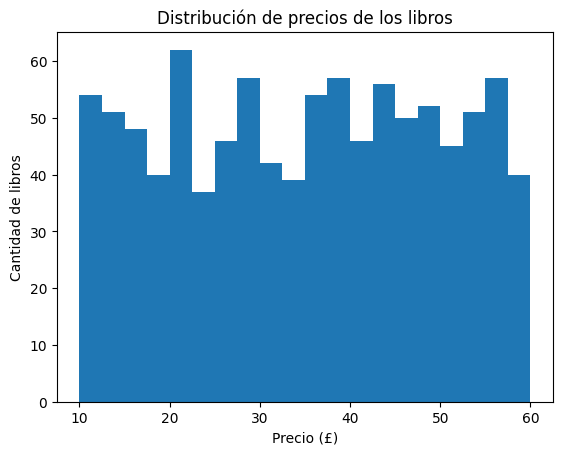

In [29]:
df["precios"].plot(kind="hist", bins=20)
plt.title("Distribución de precios de los libros") 
plt.xlabel("Precio (£)") 
plt.ylabel("Cantidad de libros") 
plt.show()

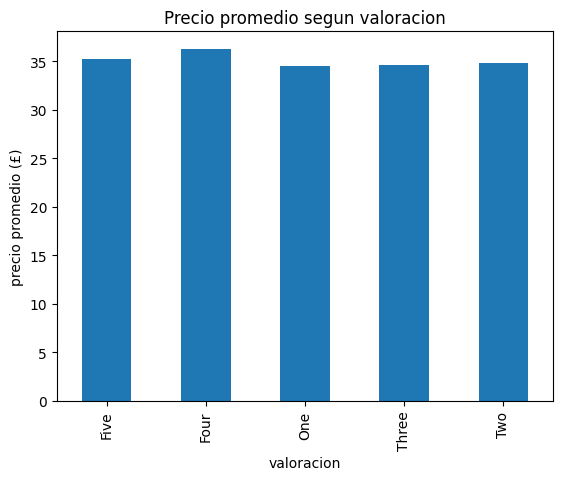

In [31]:
promedio = df.groupby("valoraciones")["precios"].mean()

promedio.plot(kind="bar")

plt.title("Precio promedio segun valoracion")
plt.xlabel("valoracion")
plt.ylabel("precio promedio (£)")
plt.show()


In [35]:
top10 = df.sort_values("precios",ascending=False).head(10)
print(top10[["titulos","precios","valoraciones"]])


                              titulos  precios valoraciones
632        The Perfect Play (Play ...    59.99        Three
601            Last One Home (New ...    59.98        Three
844  Civilization and Its Discontents    59.95          Two
544    The Barefoot Contessa Cookbook    59.92         Five
350                The Diary of a ...    59.90        Three
641        The Bone Hunters (Lexy ...    59.71        Three
117      Thomas Jefferson and the ...    59.64          One
371      Boar Island (Anna Pigeon ...    59.48        Three
377         The Improbability of Love    59.45          One
533           The Man Who Mistook ...    59.45         Four


¿Cuántos libros hay de cada valoración?

In [36]:
print(df["valoraciones"].value_counts())

valoraciones
One      222
Three    201
Two      193
Five     192
Four     176
Name: count, dtype: int64


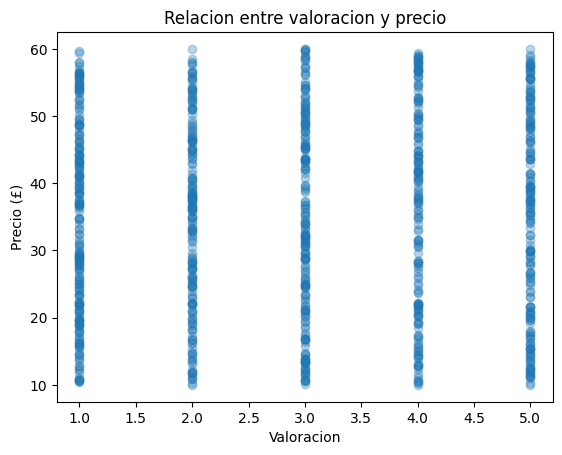

In [39]:
orden ={
    "One": 1,
    "Two": 2,
    "Three":3,
    "Four":4,
    "Five":5

    }

df["rating_num"]=df["valoraciones"].map(orden)
plt.scatter(
    df["rating_num"],
    df["precios"],
    alpha=0.3
    )

plt.title("Relacion entre valoracion y precio")
plt.xlabel("Valoracion")
plt.ylabel("Precio (£)")
plt.show()

PRECIO PROMEDIO DE LOS LIBROS

In [41]:
df["precios"].mean()

np.float64(35.07399390243902)

EL LIBRO MAS CARO

In [42]:
df.loc[df["precios"].idxmax()]

titulos         The Perfect Play (Play ...
precios                              59.99
valoraciones                         Three
rating_num                               3
Name: 632, dtype: object

¿QUE PORCENTAJE DE LOS LIBROS TIENE 5 ESTRELLAS? 

In [43]:
df["valoraciones"].value_counts(normalize=True) *100

valoraciones
One      22.560976
Three    20.426829
Two      19.613821
Five     19.512195
Four     17.886179
Name: proportion, dtype: float64

TOP 10 LIBROS MAS CAROS

In [44]:
df.sort_values("precios",ascending=False).head(10)

,titulos,precios,valoraciones,rating_num
632,The Perfect Play (Play ...,59.99,Three,3
601,Last One Home (New ...,59.98,Three,3
844,Civilization and Its Discontents,59.95,Two,2
544,The Barefoot Contessa Cookbook,59.92,Five,5
350,The Diary of a ...,59.90,Three,3
641,The Bone Hunters (Lexy ...,59.71,Three,3
117,Thomas Jefferson and the ...,59.64,One,1
371,Boar Island (Anna Pigeon ...,59.48,Three,3
377,The Improbability of Love,59.45,One,1
533,The Man Who Mistook ...,59.45,Four,4


TOP 10 LIBROS MAS BARATOS

In [45]:
df.sort_values("precios").head(10)

,titulos,precios,valoraciones,rating_num
622,An Abundance of Katherines,10.00,Five,5
485,The Origin of Species,10.01,Four,4
700,The Tipping Point: How ...,10.02,Two,2
68,Patience,10.16,Three,3
286,Greek Mythic History,10.23,Five,5
542,The Fellowship of the ...,10.27,Two,2
463,History of Beauty,10.29,Four,4
226,The Lucifer Effect: Understanding ...,10.40,One,1
418,NaNo What Now? Finding ...,10.41,Four,4
258,Pet Sematary,10.56,Three,3


In [46]:
df["precios"].describe()

count    984.000000
mean      35.073994
std       14.440539
min       10.000000
25%       22.107500
50%       36.025000
75%       47.342500
max       59.990000
Name: precios, dtype: float64